In [48]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

import joblib

# Feature-Engineered Dataset Load

In [49]:
df = pd.read_csv(
    "../data/processed/feature_engineered_customer_churn.csv"
)

print("Dataset loaded successfully!")

print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (7043, 25)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Average_Monthly_Spend,Customer_Lifetime_Months,Service_Count,High_Monthly_Charge,Short_Tenure
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Yes,Electronic check,29.85,29.85,0,29.850000,1,1,0,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,Mailed check,56.95,1889.50,0,55.573529,34,3,0,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Yes,Mailed check,53.85,108.15,1,54.075000,2,3,0,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,Bank transfer (automatic),42.30,1840.75,0,40.905556,45,3,0,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Yes,Electronic check,70.70,151.65,1,75.825000,2,1,1,1


# Check Target

In [50]:
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


# Separate Features and Target

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [52]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 24)
y shape: (7043,)


# Remove Customer ID

In [53]:
if "customerID" in X.columns:
    X = X.drop("customerID", axis=1)

# Identify Numerical and Categorical Columns

In [54]:
categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)

Categorical Columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Average_Monthly_Spend', 'Customer_Lifetime_Months', 'Service_Count', 'High_Monthly_Charge', 'Short_Tenure']


# Train/Test Split

In [55]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20,random_state=42,stratify=y)

In [56]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 24)
Testing data: (1409, 24)


# Preprocessing

## Numerical data

In [57]:
StandardScaler()

,copy,True
,with_mean,True
,with_std,True


# Categorical data

In [58]:
OneHotEncoder()

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [59]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_columns
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ]
)

# Create ML Models

## 1. Logistic Regression

In [60]:
logistic_model = LogisticRegression(
    max_iter=1000
)

## 2. Decision Tree

In [61]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

## 3. Random Forest

In [62]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Create Pipelines

### Raw Features
     ↓
### Preprocessing
     ↓
### Machine Learning Model

## Logistic Regression

In [63]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            logistic_model
        )
    ]
)

## Decision Tree

In [64]:
decision_tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            decision_tree_model
        )
    ]
)

## Random Forest

In [65]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            random_forest_model
        )
    ]
)

# Train Logistic Regression

In [66]:
logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


# Prediction

In [67]:
y_pred_lr = logistic_pipeline.predict(
    X_test
)

y_prob_lr = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

# Evaluate Logistic Regression

In [68]:
lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

lr_precision = precision_score(
    y_test,
    y_pred_lr
)

lr_recall = recall_score(
    y_test,
    y_pred_lr
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr
)

lr_auc = roc_auc_score(
    y_test,
    y_prob_lr
)

print("Logistic Regression")
print("==========================")

print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))
print("ROC-AUC  :", round(lr_auc, 4))

Logistic Regression
Accuracy : 0.8027
Precision: 0.6611
Recall   : 0.5267
F1 Score : 0.5863
ROC-AUC  : 0.8417


# Train Decision Tree

In [69]:
decision_tree_pipeline.fit(
    X_train,
    y_train
)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


# Prediction

In [70]:
y_pred_dt = decision_tree_pipeline.predict(
    X_test
)

y_prob_dt = decision_tree_pipeline.predict_proba(
    X_test
)[:, 1]

# Evaluation

In [71]:
dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

dt_precision = precision_score(
    y_test,
    y_pred_dt
)

dt_recall = recall_score(
    y_test,
    y_pred_dt
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt
)

dt_auc = roc_auc_score(
    y_test,
    y_prob_dt
)

print("Decision Tree")
print("==========================")

print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1 Score :", round(dt_f1, 4))
print("ROC-AUC  :", round(dt_auc, 4))

Decision Tree
Accuracy : 0.7984
Precision: 0.6347
Recall   : 0.5668
F1 Score : 0.5989
ROC-AUC  : 0.831


# Train Random Forest

In [72]:
random_forest_pipeline.fit(
    X_train,
    y_train
)
print("Random Forest trained successfully!")

Random Forest trained successfully!


# Prediction

In [73]:
y_pred_rf = random_forest_pipeline.predict(
    X_test
)

y_prob_rf = random_forest_pipeline.predict_proba(
    X_test
)[:, 1]

# Evaluation

In [74]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

print("Random Forest")
print("==========================")

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

Random Forest
Accuracy : 0.785
Precision: 0.6212
Recall   : 0.4866
F1 Score : 0.5457
ROC-AUC  : 0.8236


# Model Comparison

In [75]:
results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],

    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision
    ],

    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall
    ],

    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1
    ],

    "ROC-AUC": [
        lr_auc,
        dt_auc,
        rf_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.802697,0.661074,0.526738,0.586310,0.841740
1,Decision Tree,0.798439,0.634731,0.566845,0.598870,0.830975
2,Random Forest,0.784954,0.621160,0.486631,0.545727,0.823599


# Best Model

## Hum ROC-AUC ke basis par best model select karenge.

In [76]:
best_row = results.loc[
    results["ROC-AUC"].idxmax()
]
print("Best Model:")
print(best_row["Model"])

print(
    "\nBest ROC-AUC:",
    round(best_row["ROC-AUC"], 4)
)

Best Model:
Logistic Regression

Best ROC-AUC: 0.8417


# Save Best Model

In [77]:
trained_models = {

    "Logistic Regression":
        logistic_pipeline,

    "Decision Tree":
        decision_tree_pipeline,

    "Random Forest":
        random_forest_pipeline
}

## Best model select

In [78]:
best_model_name = best_row["Model"]

best_model = trained_models[
    best_model_name
]

## Save

In [79]:
import os
import joblib

# Project ka exact path
project_path = r"C:\Users\AA\Desktop\Internship\customer_churn_project"

# Models folder ka path
models_folder = os.path.join(
    project_path,
    "models"
)

# Agar models folder nahi hai to create karega
os.makedirs(
    models_folder,
    exist_ok=True
)

# Complete model file path
model_path = os.path.join(
    models_folder,
    "churn_model.pkl"
)

# Save model
joblib.dump(
    best_model,
    model_path
)

print("✅ Best model saved successfully!")
print("Model saved at:")
print(model_path)

✅ Best model saved successfully!
Model saved at:
C:\Users\AA\Desktop\Internship\customer_churn_project\models\churn_model.pkl


In [80]:
print(os.path.exists(model_path))

True


In [81]:
results_path = os.path.join(
    models_folder,
    "model_results.csv"
)

results.to_csv(
    results_path,
    index=False
)

print("✅ Model results saved successfully!")
print(results_path)

✅ Model results saved successfully!
C:\Users\AA\Desktop\Internship\customer_churn_project\models\model_results.csv


# Feature Importance

## Check Best Model

In [82]:
print("Best Model:", best_model_name)

Best Model: Logistic Regression


## Extract the Preprocessor and Model

In [83]:
preprocessor = best_model.named_steps["preprocessor"]

model = best_model.named_steps["model"]

print("Model:", model)

Model: LogisticRegression(max_iter=1000)


## Get Feature Names

In [84]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))

print("\nFirst 20 features:")
print(feature_names[:20])

Number of features: 50

First 20 features:
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'num__Average_Monthly_Spend'
 'num__Customer_Lifetime_Months' 'num__Service_Count'
 'num__High_Monthly_Charge' 'num__Short_Tenure' 'cat__gender_Female'
 'cat__gender_Male' 'cat__Partner_No' 'cat__Partner_Yes'
 'cat__Dependents_No' 'cat__Dependents_Yes' 'cat__PhoneService_No'
 'cat__PhoneService_Yes' 'cat__MultipleLines_No'
 'cat__MultipleLines_No phone service' 'cat__MultipleLines_Yes']


# Calculate Feature Importance

In [85]:
if hasattr(model, "feature_importances_"):

    importance = model.feature_importances_

elif hasattr(model, "coef_"):

    importance = np.abs(
        model.coef_[0]
    )

else:

    raise ValueError(
        "This model does not support feature importance."
    )

# Create Feature Importance Table

In [86]:
feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importance

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
43,cat__Contract_Two year,0.833214
20,cat__InternetService_DSL,0.718671
21,cat__InternetService_Fiber optic,0.686533
41,cat__Contract_Month-to-month,0.613896
2,num__MonthlyCharges,0.507333
1,num__tenure,0.399898
5,num__Customer_Lifetime_Months,0.399898
44,cat__PaperlessBilling_No,0.344604
17,cat__MultipleLines_No,0.314259
30,cat__DeviceProtection_No internet service,0.277057


# Feature Importance Graph

In [87]:
import matplotlib.pyplot as plt

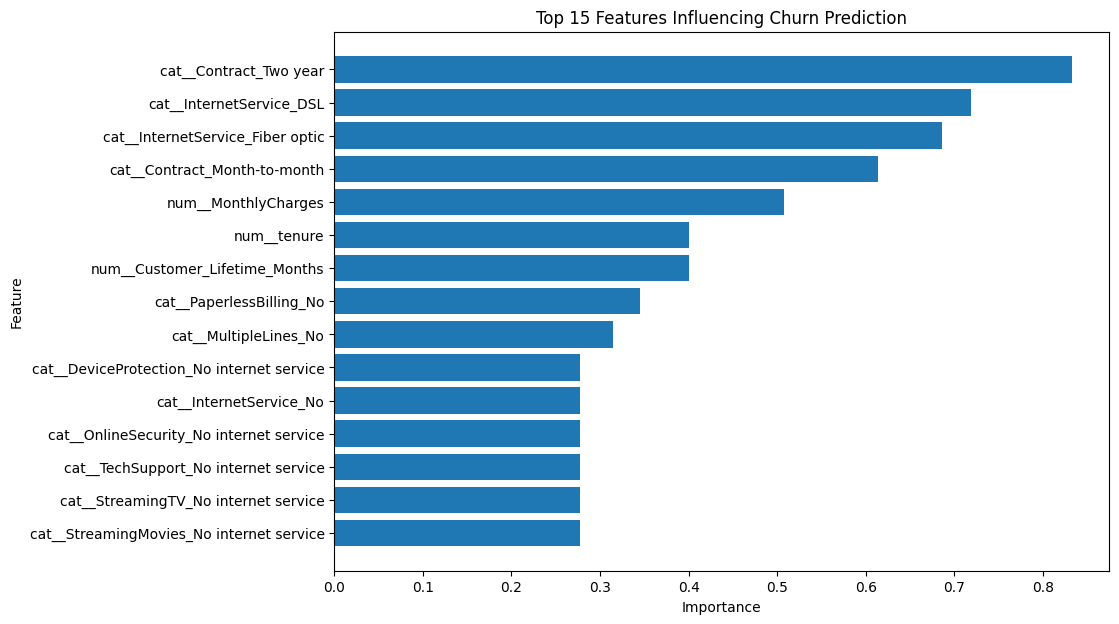

In [88]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "Top 15 Features Influencing Churn Prediction"
)

plt.gca().invert_yaxis()

plt.show()

# Save Feature Importance

In [89]:
feature_importance.to_csv(
    "../models/feature_importance.csv",
    index=False
)

print("✅ Feature importance saved!")

✅ Feature importance saved!


# Business Interpretation

In [90]:
print(
    feature_importance.head(10)
)

                                      Feature  Importance
43                     cat__Contract_Two year    0.833214
20                   cat__InternetService_DSL    0.718671
21           cat__InternetService_Fiber optic    0.686533
41               cat__Contract_Month-to-month    0.613896
2                         num__MonthlyCharges    0.507333
1                                 num__tenure    0.399898
5               num__Customer_Lifetime_Months    0.399898
44                   cat__PaperlessBilling_No    0.344604
17                      cat__MultipleLines_No    0.314259
30  cat__DeviceProtection_No internet service    0.277057
